In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

/Users/AugustJnr/anaconda3/envs/stock-predictions-env/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker,start,end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600
2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000
2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000
2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600
2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000
...,...,...,...,...,...
2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800


# 2. Data Exploration and Visualization

In [3]:
type(df)

pandas.DataFrame

In [4]:
df.shape

(2513, 5)

In [5]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,120.729912,121.934528,119.414725,120.628074,9.818259e+07
std,75.378062,76.109520,74.589106,75.328097,5.598535e+07
min,20.584812,20.887872,20.386576,20.507347,1.791060e+07
25%,44.218651,44.454476,43.864888,44.159696,5.895310e+07
50%,127.283302,128.070688,125.020312,126.639368,8.626400e+07
75%,176.541016,177.941500,174.698364,176.284041,1.192848e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [7]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [8]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600
2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000
2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000
2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600
2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000


In [9]:
df = df.reset_index()

In [10]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000
...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600


In [11]:
df['Price Ticker'] = ''

In [12]:
df

Price,Date,Close,High,Low,Open,Volume,Price Ticker
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,
...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600,


In [13]:
df.index.name = ""

In [14]:
df.head()

Price,Date,Close,High,Low,Open,Volume,Price Ticker
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
,,,,,,,
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,


In [15]:
df_cop = df.copy()

In [16]:
df_cop

Price,Date,Close,High,Low,Open,Volume,Price Ticker
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
,,,,,,,
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,
...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,


In [17]:
df_cop.index.name = None

In [18]:
df_cop

Price,Date,Close,High,Low,Open,Volume,Price Ticker
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,
...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600,


In [19]:
df_cop.columns.names = [None, None]

In [20]:
df_cop

,Date,Close,High,Low,Open,Volume,Price Ticker
,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,
...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600,


In [21]:
df_cop.columns = [' '.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

In [22]:
df_cop

,Date,Close AAPL,High AAPL,Low AAPL,Open AAPL,Volume AAPL,Price Ticker
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,
...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600,
2511,2026-04-10,260.480011,262.190002,259.019989,259.980011,31291500,


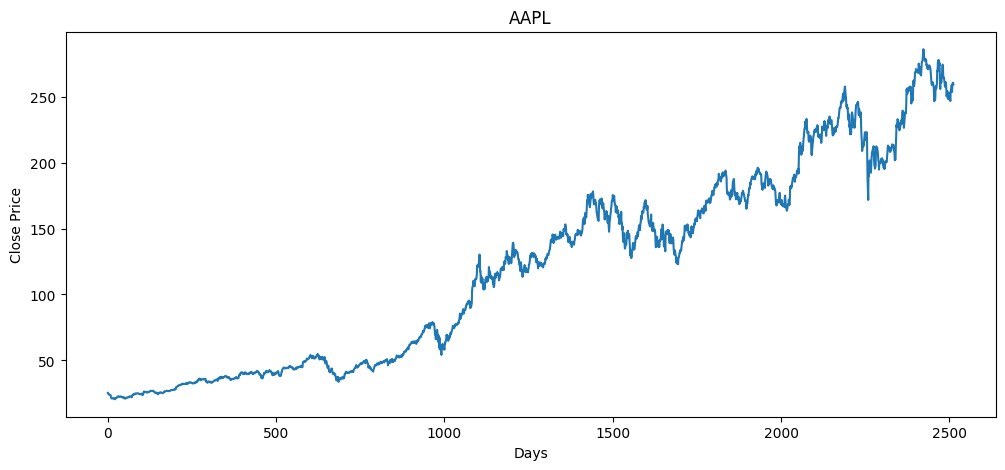

In [23]:
plt.figure(figsize=(12,5));
plt.plot(df_cop['Close AAPL']);
plt.title(ticker);
plt.xlabel('Days');
plt.ylabel('Close Price');

# 3. Feature Engineering - 
### Create new features from our existing data that'll help our model to make better predictions

### First we create the moving average which will give the smooth pattern of the stock trends from our data

In [24]:
# [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# MA of 5 days => null null null null 30 40 ...

In [25]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[2:7])/5)

50.0


In [26]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [27]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


## 100 Days of Moving Average

In [28]:
df_cop['MA_100'] = df_cop['Close AAPL'].rolling(100).mean()
df_cop.head()

,Date,Close AAPL,High AAPL,Low AAPL,Open AAPL,Volume AAPL,Price Ticker,MA_100
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,,NaN
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,,NaN
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,,NaN
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,,NaN
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,,NaN


In [29]:
df_cop.head(103)

,Date,Close AAPL,High AAPL,Low AAPL,Open AAPL,Volume AAPL,Price Ticker,MA_100
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,,NaN
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,,NaN
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,,NaN
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,,NaN
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,,NaN
...,...,...,...,...,...,...,...,...
98,2016-09-01,24.451178,24.467214,24.196883,24.316011,106806000,,NaN
99,2016-09-02,24.680265,24.742120,24.471789,24.673391,107210000,,22.869266
100,2016-09-06,24.673399,24.810857,24.629872,24.719219,107521600,,22.862115
101,2016-09-07,24.824596,24.916234,24.529065,24.703177,169457200,,22.861572


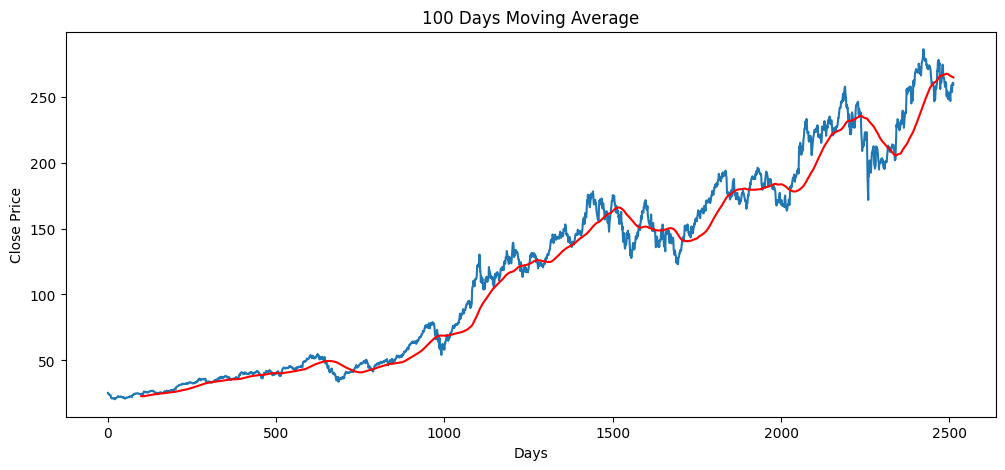

In [30]:
plt.figure(figsize=(12,5));
plt.plot(df_cop['Close AAPL']);
plt.plot(df_cop['MA_100'], 'r');
plt.title('100 Days Moving Average');
plt.xlabel('Days');
plt.ylabel('Close Price');

In [31]:
df_cop['MA_200'] = df_cop['Close AAPL'].rolling(200).mean()
df_cop

,Date,Close AAPL,High AAPL,Low AAPL,Open AAPL,Volume AAPL,Price Ticker,MA_100,MA_200
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,,NaN,NaN
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,,NaN,NaN
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,,NaN,NaN
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,,NaN,NaN
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2508,2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000,,265.074456,249.410618
2509,2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800,,264.913530,249.703167
2510,2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600,,264.786286,250.001173
2511,2026-04-10,260.480011,262.190002,259.019989,259.980011,31291500,,264.664138,250.305112


In [32]:
df_cop.head(203)

,Date,Close AAPL,High AAPL,Low AAPL,Open AAPL,Volume AAPL,Price Ticker,MA_100,MA_200
0,2016-04-14,25.388458,25.454138,25.214069,25.279749,101895600,,NaN,NaN
1,2016-04-15,24.878881,25.433760,24.851705,25.390728,187756000,,NaN,NaN
2,2016-04-18,24.342121,24.675046,24.219821,24.661458,243286000,,NaN,NaN
3,2016-04-19,24.213028,24.459891,24.059021,24.432713,129539600,,NaN,NaN
4,2016-04-20,24.262842,24.480263,24.020508,24.151867,122444000,,NaN,NaN
...,...,...,...,...,...,...,...,...,...
198,2017-01-26,28.079124,28.194259,28.000832,28.016951,105350400,,26.174746,NaN
199,2017-01-27,28.081425,28.173533,28.000831,28.125177,82251600,,26.208758,24.539012
200,2017-01-30,28.007730,28.007730,27.784370,27.846542,121510000,,26.242101,24.552108
201,2017-01-31,27.943266,27.952477,27.775170,27.897213,196804000,,26.273288,24.567430


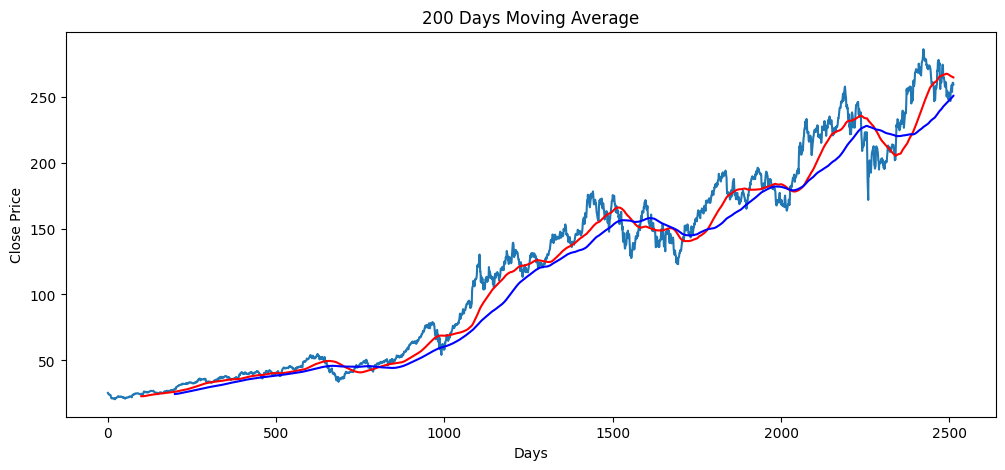

In [33]:
plt.figure(figsize=(12,5));
plt.plot(df_cop['Close AAPL']);
plt.plot(df_cop['MA_100'], 'r');
plt.plot(df_cop['MA_200'], 'b');
plt.title('200 Days Moving Average');
plt.xlabel('Days');
plt.ylabel('Close Price');

### Calculating percentage change in each trading session

In [34]:
df_cop['Percentage Changed'] = df_cop['Close AAPL'].pct_change()
df_cop[['Close AAPL', 'Percentage Changed']]

,Close AAPL,Percentage Changed
0,25.388458,NaN
1,24.878881,-0.020071
2,24.342121,-0.021575
3,24.213028,-0.005303
4,24.262842,0.002057
...,...,...
2508,253.500000,-0.020706
2509,258.899994,0.021302
2510,260.489990,0.006141
2511,260.480011,-0.000038


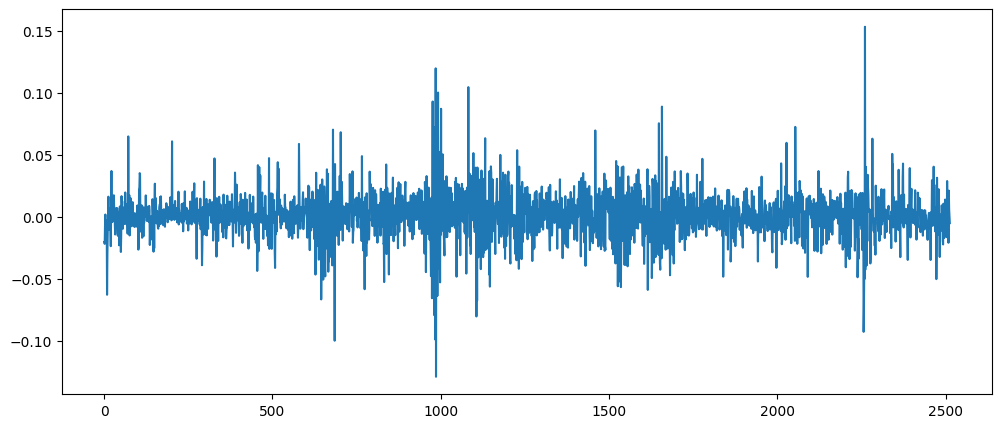

In [35]:
plt.figure(figsize=(12,5));
plt.plot(df_cop['Percentage Changed']);

## 4. Data Preprocessing

In [36]:
df_cop.shape

(2513, 10)

In [37]:
# Splitting data into tarining and testing dataset
training_data = pd.DataFrame(df_cop['Close AAPL'][0:int(len(df_cop) * 0.7)])
testing_data = pd.DataFrame(df_cop['Close AAPL'][int(len(df_cop) * 0.7): int(len(df_cop))])

print(training_data)
print(testing_data)

      Close AAPL
0      25.388458
1      24.878881
2      24.342121
3      24.213028
4      24.262842
...          ...
1754  163.797043
1755  163.264771
1756  161.421478
1757  162.308609
1758  159.716171

[1759 rows x 1 columns]
      Close AAPL
1759  158.503754
1760  157.813721
1761  163.195755
1762  162.850769
1763  162.870483
...          ...
2508  253.500000
2509  258.899994
2510  260.489990
2511  260.480011
2512  259.200012

[754 rows x 1 columns]


In [38]:
type(training_data)

pandas.DataFrame

In [39]:
testing_data

,Close AAPL
1759,158.503754
1760,157.813721
1761,163.195755
1762,162.850769
1763,162.870483
...,...
2508,253.500000
2509,258.899994
2510,260.489990
2511,260.480011


In [40]:
# For LSTM Model the data must be scaled down between 0 and 1(compressing the data to fit into 0 and 1)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [41]:
training_data_array = scaler.fit_transform(training_data)
training_data_array

array([[0.03049569],
       [0.02726067],
       [0.02385307],
       ...,
       [0.89409393],
       [0.89972583],
       [0.88326788]])

In [42]:
type(training_data_array)

numpy.ndarray

In [43]:
training_data_array.shape

(1759, 1)

# 5. Sequence Creation
#### Create the sequence cos LSTM models wants the input as sequence of data

In [44]:
x_train = []
y_train = []

for i in range(100, training_data_array.shape[0]):
    x_train.append(training_data_array[i-100: i])
    y_train.append(training_data_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [45]:
x_train

array([[[0.03049569],
        [0.02726067],
        [0.02385307],
        ...,
        [0.02362916],
        [0.02454541],
        [0.02599976]],

       [[0.02726067],
        [0.02385307],
        [0.02303353],
        ...,
        [0.02454541],
        [0.02599976],
        [0.02595617]],

       [[0.02385307],
        [0.02303353],
        [0.02334977],
        ...,
        [0.02599976],
        [0.02595617],
        [0.02691604]],

       ...,

       [[0.71201958],
        [0.78699868],
        [0.80468116],
        ...,
        [0.9012276 ],
        [0.90917507],
        [0.90579597]],

       [[0.78699868],
        [0.80468116],
        [0.79580858],
        ...,
        [0.90917507],
        [0.90579597],
        [0.89409393]],

       [[0.80468116],
        [0.79580858],
        [0.80680551],
        ...,
        [0.90579597],
        [0.89409393],
        [0.89972583]]])

In [46]:
x_train.ndim

3

In [47]:
y_train.ndim

1

In [48]:
x_train.shape

(1659, 100, 1)

# 6. Create the ML Model to train the data

In [49]:
import tensorflow as tf
print(tf.__version__)

2026-04-14 07:41:02.115171: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


In [50]:
import tensorflow.keras as ks

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

In [52]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [53]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 168ms/step - loss: 0.0196
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 7.4911e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 7.2068e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 7.1264e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 6.9223e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 6.7088e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 5.8013e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 6.1693e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 5.4429e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 5.4402e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - loss: 5.1222e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 4.7899e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 5.3905e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 4.4843e-04
Epoc

In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [55]:
# save the model
model.save('stock_predictions_model.keras')

# 8. Preparing Test Data

In [56]:
testing_data

,Close AAPL
1759,158.503754
1760,157.813721
1761,163.195755
1762,162.850769
1763,162.870483
...,...
2508,253.500000
2509,258.899994
2510,260.489990
2511,260.480011


In [57]:
past_100_days = training_data.tail(100)

In [58]:
past_100_days

,Close AAPL
1659,145.939682
1660,147.671906
1661,146.441650
1662,148.341217
1663,148.902191
...,...
1754,163.797043
1755,163.264771
1756,161.421478
1757,162.308609


In [59]:
final_testing_data = pd.concat([past_100_days, testing_data], ignore_index=True)
final_testing_data

,Close AAPL
0,145.939682
1,147.671906
2,146.441650
3,148.341217
4,148.902191
...,...
849,253.500000
850,258.899994
851,260.489990
852,260.480011


In [60]:
final_testing_data_array = scaler.fit_transform(final_testing_data)
final_testing_data_array

array([[1.40554237e-01],
       [1.51189490e-01],
       [1.43636149e-01],
       [1.55298831e-01],
       [1.58743018e-01],
       [1.38922830e-01],
       [1.52035641e-01],
       [1.57413834e-01],
       [1.39527183e-01],
       [1.16020823e-01],
       [9.75903386e-02],
       [1.39043588e-01],
       [1.40735703e-01],
       [1.37714217e-01],
       [1.30583951e-01],
       [1.08104927e-01],
       [9.62007285e-02],
       [1.06533664e-01],
       [1.03572885e-01],
       [1.17652324e-01],
       [1.23574257e-01],
       [1.09917612e-01],
       [6.93707525e-02],
       [5.73457961e-02],
       [4.44141690e-02],
       [4.39911872e-02],
       [6.30257440e-02],
       [4.35681117e-02],
       [4.13324443e-02],
       [3.02743035e-02],
       [6.16358998e-03],
       [2.77363188e-02],
       [2.96698564e-02],
       [3.02036191e-04],
       [8.09722118e-03],
       [0.00000000e+00],
       [2.77966511e-02],
       [3.09991341e-02],
       [3.45041217e-02],
       [5.11820656e-02],


In [61]:
final_testing_data_array.shape

(854, 1)

In [62]:
x_test = []
y_test = []

for i in range(100, final_testing_data_array.shape[0]):
    x_test.append(final_testing_data_array[i-100: i])
    y_test.append(final_testing_data_array[i,0])



In [63]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [64]:
x_test

array([[[0.14055424],
        [0.15118949],
        [0.14363615],
        ...,
        [0.23560711],
        [0.24105378],
        [0.22513711]],

       [[0.15118949],
        [0.14363615],
        [0.15529883],
        ...,
        [0.24105378],
        [0.22513711],
        [0.21769329]],

       [[0.14363615],
        [0.15529883],
        [0.15874302],
        ...,
        [0.22513711],
        [0.21769329],
        [0.21345672]],

       ...,

       [[0.92197667],
        [0.91878711],
        [0.91547465],
        ...,
        [0.83384581],
        [0.80093735],
        [0.83409145]],

       [[0.91878711],
        [0.91547465],
        [0.88511177],
        ...,
        [0.80093735],
        [0.83409145],
        [0.84385347]],

       [[0.91547465],
        [0.88511177],
        [0.88498923],
        ...,
        [0.83409145],
        [0.84385347],
        [0.8437922 ]]])

# 9.Make Predictions

In [65]:
y_predict = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


In [66]:
y_predict

array([[0.23472844],
       [0.22553132],
       [0.21956652],
       [0.23760028],
       [0.24772972],
       [0.25154454],
       [0.25665718],
       [0.26275533],
       [0.2613522 ],
       [0.25350574],
       [0.25038728],
       [0.243907  ],
       [0.24109371],
       [0.25775614],
       [0.27213556],
       [0.2776241 ],
       [0.27451462],
       [0.26765072],
       [0.25789684],
       [0.28271958],
       [0.29656807],
       [0.29442447],
       [0.29828998],
       [0.30060542],
       [0.2974881 ],
       [0.2937229 ],
       [0.29226682],
       [0.29458594],
       [0.30535668],
       [0.31100824],
       [0.30896392],
       [0.2969801 ],
       [0.29244813],
       [0.29595992],
       [0.30796117],
       [0.32099396],
       [0.32576212],
       [0.33758202],
       [0.34535274],
       [0.3416881 ],
       [0.3373295 ],
       [0.3297904 ],
       [0.33801168],
       [0.3441874 ],
       [0.35816282],
       [0.36180663],
       [0.3647278 ],
       [0.373

In [67]:
y_test

array([0.21769329, 0.21345672, 0.24650055, 0.24438246, 0.2445035 ,
       0.25200793, 0.25902821, 0.25309719, 0.2432323 , 0.2451086 ,
       0.23566772, 0.23560711, 0.26374875, 0.27143484, 0.27088997,
       0.2645355 , 0.25793895, 0.2478926 , 0.29497717, 0.29455316,
       0.28408345, 0.29491637, 0.29606625, 0.29036981, 0.28733933,
       0.28733933, 0.29109689, 0.30539901, 0.30606576, 0.300248  ,
       0.28424852, 0.2859456 , 0.29291501, 0.30770213, 0.31903505,
       0.31873189, 0.33594317, 0.34115527, 0.33285264, 0.33061032,
       0.32218647, 0.33885252, 0.34121588, 0.35836664, 0.35545758,
       0.35933636, 0.37182065, 0.36521501, 0.36576025, 0.35939707,
       0.37782044, 0.37588109, 0.36733601, 0.38424442, 0.391456  ,
       0.39351667, 0.4200611 , 0.41090998, 0.40406161, 0.40697067,
       0.4001223 , 0.3875775 , 0.38436546, 0.39460752, 0.39927409,
       0.4001831 , 0.42018232, 0.41860666, 0.42690909, 0.41497042,
       0.40775855, 0.41266749, 0.41793982, 0.42327304, 0.41551

In [68]:
y_predict = scaler.inverse_transform(y_predict.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [69]:
y_predict

array([161.27837, 159.78038, 158.80887, 161.74612, 163.39595, 164.01729,
       164.85002, 165.84326, 165.61473, 164.33673, 163.82881, 162.77333,
       162.31511, 165.02902, 167.37106, 168.26503, 167.75856, 166.64061,
       165.05193, 169.09496, 171.35052, 171.00139, 171.631  , 172.00812,
       171.50038, 170.88713, 170.64998, 171.0277 , 172.78198, 173.70248,
       173.36952, 171.41765, 170.6795 , 171.2515 , 173.20619, 175.3289 ,
       176.10555, 178.0307 , 179.29637, 178.69948, 177.98958, 176.76164,
       178.10068, 179.10657, 181.38281, 181.9763 , 182.45209, 183.929  ,
       183.72044, 183.55516, 182.76312, 184.52867, 185.10936, 184.2964 ,
       185.83739, 187.31451, 188.02971, 191.2104 , 191.24728, 190.20805,
       190.07721, 189.27826, 187.59653, 186.73346, 187.78613, 188.87708,
       189.40198, 191.8461 , 192.48027, 193.46074, 192.27028, 190.88129,
       190.98999, 191.75221, 192.70819, 192.1407 , 193.7586 , 194.7824 ,
       194.44536, 192.0814 , 190.26723, 183.35222, 

In [70]:
y_test

array([158.50375366, 157.8137207 , 163.195755  , 162.85076904,
       162.8704834 , 164.09277344, 165.23620605, 164.27018738,
       162.66343689, 162.96903992, 161.43135071, 161.42147827,
       166.00506592, 167.25694275, 167.16819763, 166.13320923,
       165.05879211, 163.42248535, 171.09141541, 171.02235413,
       169.3170929 , 171.08151245, 171.26879883, 170.34098816,
       169.84739685, 169.84739685, 170.45941162, 172.78887939,
       172.8974762 , 171.9499054 , 169.34397888, 169.62039185,
       170.75553894, 173.16400146, 175.00985718, 174.96047974,
       177.76377869, 178.61270142, 177.26040649, 176.89518738,
       175.52314758, 178.23764038, 178.62257385, 181.41601562,
       180.94219971, 181.57395935, 183.60734558, 182.53144836,
       182.62025452, 181.58384705, 184.58456421, 184.26869202,
       182.87690735, 185.63087463, 186.8054657 , 187.14109802,
       191.46453857, 189.9740448 , 188.85861206, 189.33242798,
       188.21699524, 186.17375183, 185.65058899, 187.31

(160.0, 292.32789154052733)

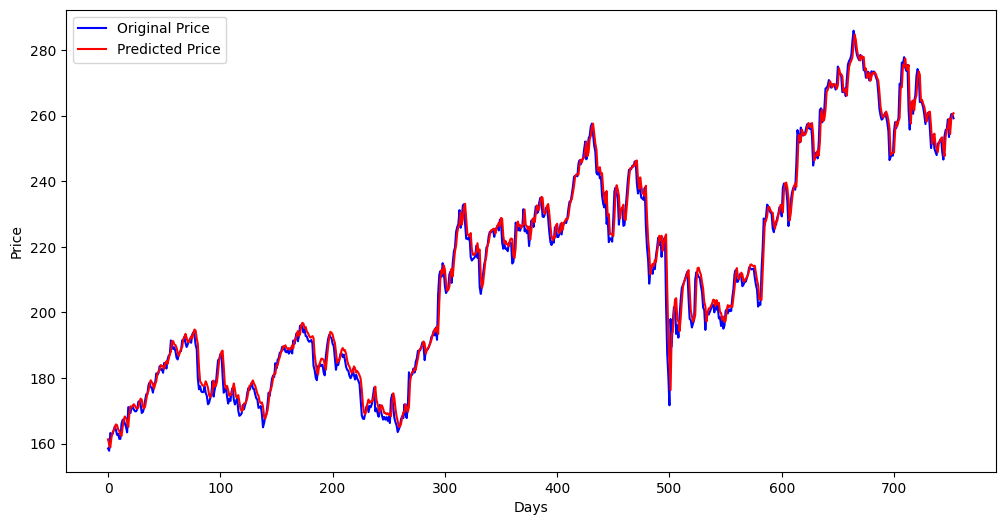

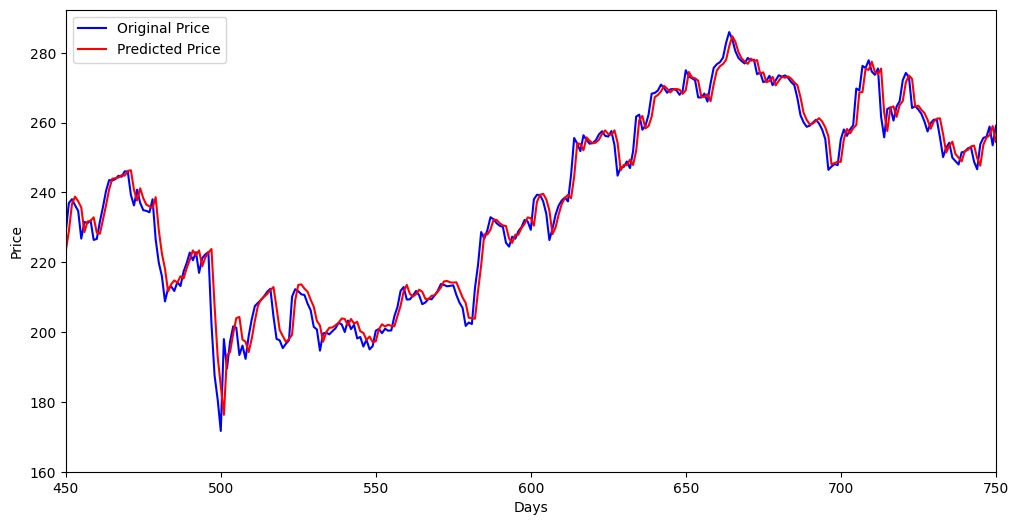

In [71]:
plt.figure(figsize=(12,6));
plt.plot(y_test, 'b', label='Original Price');
plt.plot(y_predict, 'r', label='Predicted Price');
plt.xlabel('Days');
plt.ylabel('Price');
plt.legend();

plt.figure(figsize=(12,6));
plt.plot(y_test, 'b', label='Original Price');
plt.plot(y_predict, 'r', label='Predicted Price');
plt.xlabel('Days');
plt.ylabel('Price');
plt.legend();
plt.xlim(450, 750)
plt.ylim(160)

# 10. Evaluate the Model

In [72]:
# We're going to evaluate our model under 3 metrics; Mean Square Error(MSE), Root Mean Square Error(RMSE), and R squared(R**2)

In [73]:
# Mean Square Error(MSE) - Measures the average squared difference btw the predicted and actual values. 
# A lower MSE means our model is closer to the actual value which means our model is doing well.

from sklearn.metrics import mean_squared_error, r2_score

In [75]:
mse = mean_squared_error(y_test, y_predict)
print(f"The mean squared error is {mse}")

The mean squared error is 12.789118192377886


In [77]:
rmse = np.sqrt(mse)
print(f"The root mean squre error is {rmse}")

The root mean squre error is 3.576187661795433


In [79]:
r2 = r2_score(y_test, y_predict)
print(f"The Squared root is {r2}")

The Squared root is 0.9882868370251001
